# EDA Step 3: 단변량 분석 (Univariate Analysis)

**목표**: 각 변수의 독립적인 분포를 분석하고, 변수별 생존율 관계를 파악합니다.

**분석 항목**:
- 수치형 변수 분포 (histogram, KDE)
- fare 상세 분석 (log 변환, 0원 티켓)
- 범주형 변수 countplot
- 피처-타겟 관계 (생존율 bar/boxplot)
- Chi-square 검정
- deck 특별 분석

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

df = sns.load_dataset('titanic')
print(f'Data loaded: {df.shape}')

Data loaded: (891, 15)


## 3.1 수치형 변수 분포

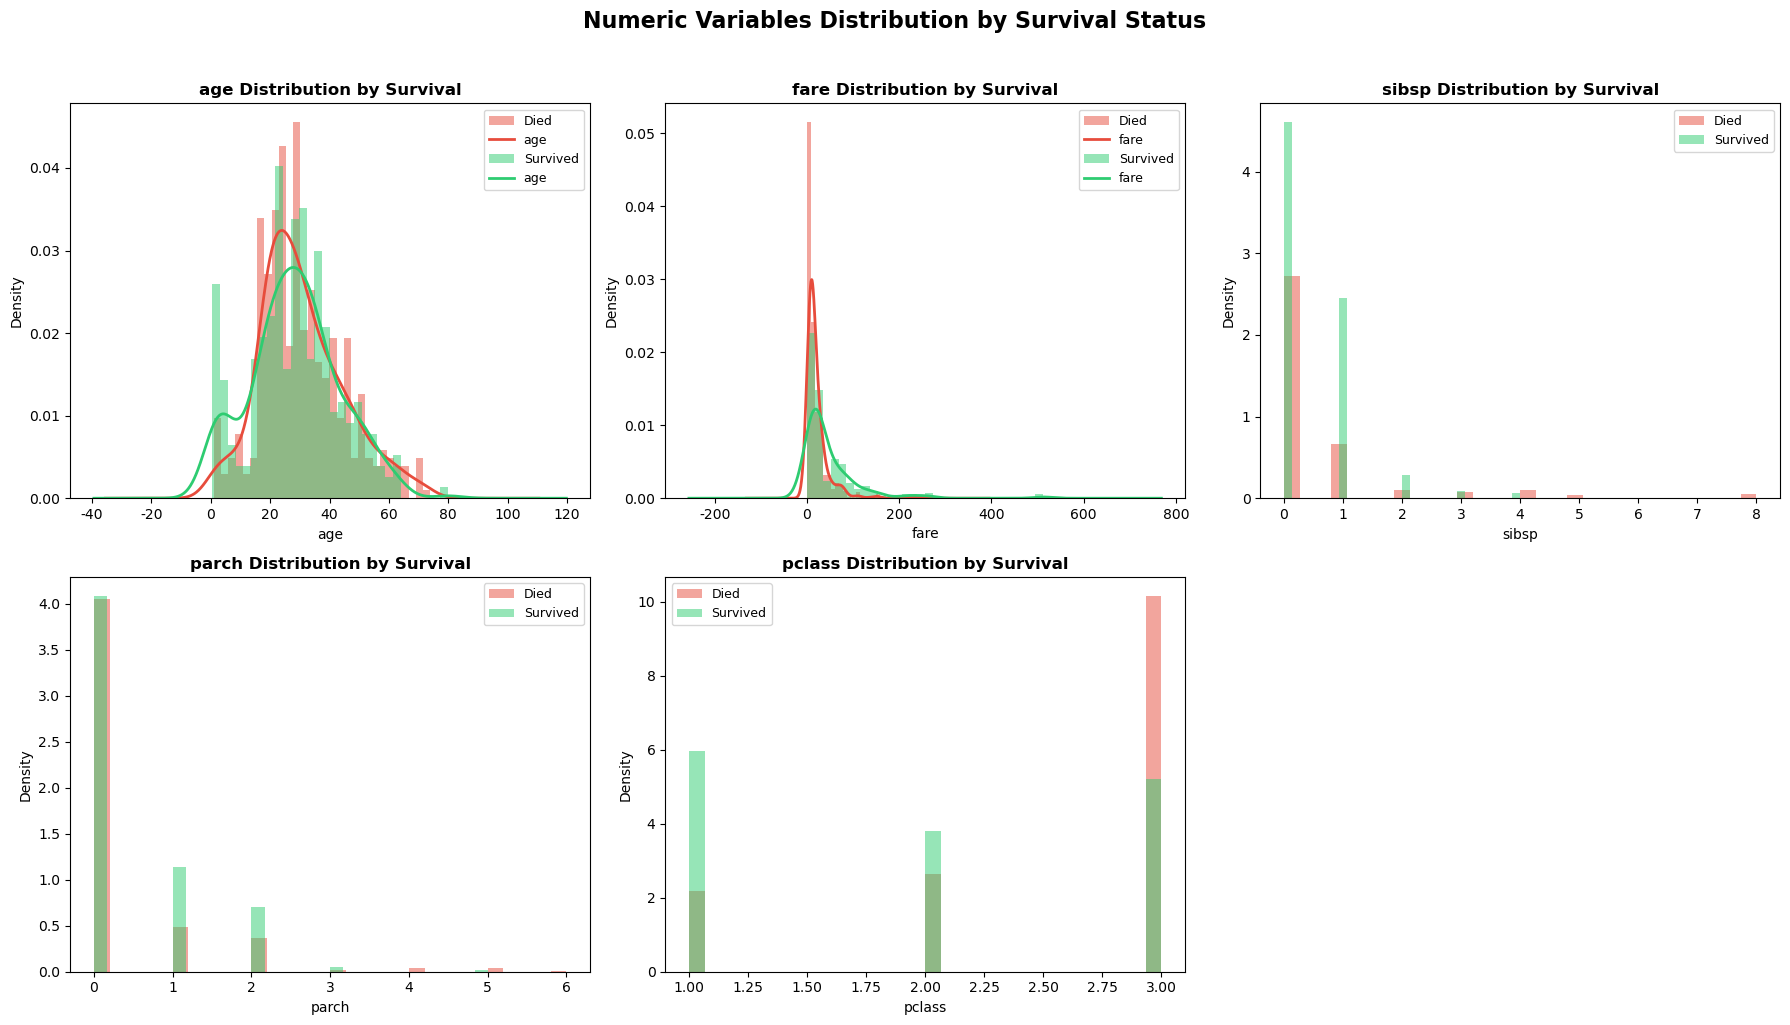

In [2]:
numeric_vars = ['age', 'fare', 'sibsp', 'parch', 'pclass']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(numeric_vars):
    ax = axes[idx]
    
    # Survived=0 vs Survived=1 분포
    for surv, color, label in [(0, '#e74c3c', 'Died'), (1, '#2ecc71', 'Survived')]:
        data = df[df['survived'] == surv][var].dropna()
        ax.hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
        if var not in ['sibsp', 'parch', 'pclass']:  # KDE for continuous vars
            data.plot.kde(ax=ax, color=color, linewidth=2)
    
    ax.set_title(f'{var} Distribution by Survival', fontsize=12, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

# 마지막 축 숨기기
axes[5].axis('off')

plt.suptitle('Numeric Variables Distribution by Survival Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_step3_numeric_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 age 상세 분석

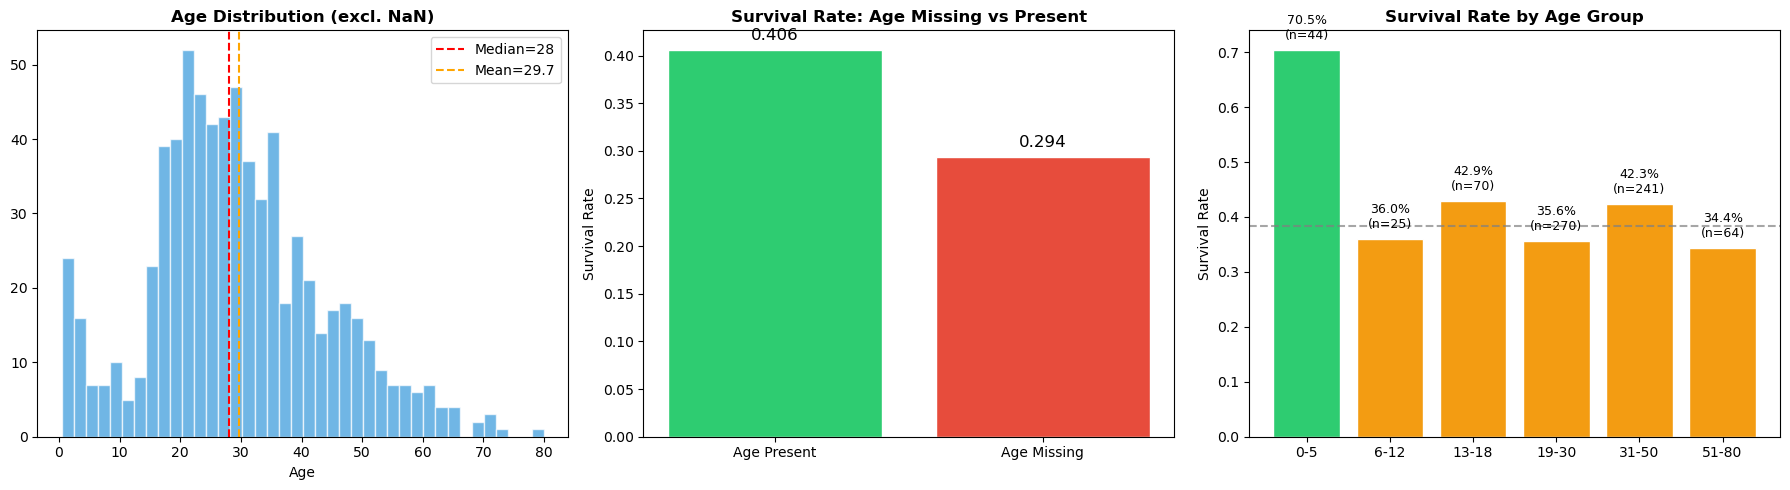

Age Missing vs Survival - Chi-square: 7.1060, p-value: 0.0077
=> Significant (age missing is  random w.r.t. survival)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# age 분포 (결측 제외)
ax = axes[0]
ax.hist(df['age'].dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.7)
ax.axvline(df['age'].median(), color='red', linestyle='--', label=f'Median={df["age"].median():.0f}')
ax.axvline(df['age'].mean(), color='orange', linestyle='--', label=f'Mean={df["age"].mean():.1f}')
ax.set_title('Age Distribution (excl. NaN)', fontsize=12, fontweight='bold')
ax.set_xlabel('Age')
ax.legend()

# age 결측 여부에 따른 생존율
ax = axes[1]
df['age_missing'] = df['age'].isnull().astype(int)
survival_by_missing = df.groupby('age_missing')['survived'].mean()
bars = ax.bar(['Age Present', 'Age Missing'], survival_by_missing.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='white')
for bar, val in zip(bars, survival_by_missing.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=12)
ax.set_title('Survival Rate: Age Missing vs Present', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate')

# age 구간별 생존율
ax = axes[2]
age_bins = [0, 5, 12, 18, 30, 50, 80]
age_labels = ['0-5', '6-12', '13-18', '19-30', '31-50', '51-80']
df['age_bin'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)
age_survival = df.groupby('age_bin', observed=True)['survived'].agg(['mean', 'count'])
colors_age = ['#2ecc71' if r > 0.5 else '#f39c12' if r > 0.3 else '#e74c3c' for r in age_survival['mean']]
bars = ax.bar(age_labels, age_survival['mean'].values, color=colors_age, edgecolor='white')
for bar, (rate, count) in zip(bars, age_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{rate:.1%}\n(n={int(count)})', ha='center', fontsize=9)
ax.set_title('Survival Rate by Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate')
ax.axhline(y=df['survived'].mean(), color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../reports/eda_step3_age_detail.png', dpi=150, bbox_inches='tight')
plt.show()

# 통계 검정: age missing vs present 생존율
from scipy.stats import chi2_contingency
ct = pd.crosstab(df['age_missing'], df['survived'])
chi2, p, dof, exp = chi2_contingency(ct)
print(f'Age Missing vs Survival - Chi-square: {chi2:.4f}, p-value: {p:.4f}')
print(f'=> {"Significant" if p < 0.05 else "Not significant"} (age missing is {"NOT" if p >= 0.05 else ""} random w.r.t. survival)')

## 3.3 fare 상세 분석

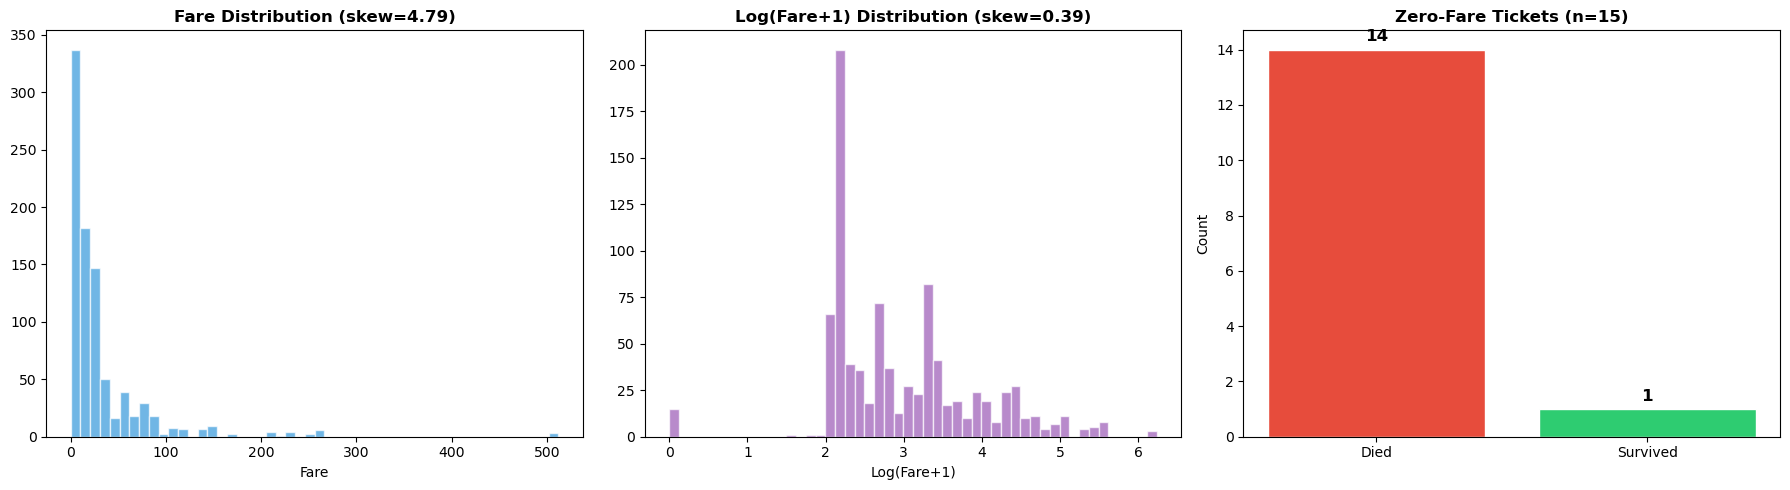


=== Zero-Fare Tickets (15 rows) ===
     pclass   sex   age embarked  survived
179       3  male  36.0        S         0
263       1  male  40.0        S         0
271       3  male  25.0        S         1
277       2  male   NaN        S         0
302       3  male  19.0        S         0
413       2  male   NaN        S         0
466       2  male   NaN        S         0
481       2  male   NaN        S         0
597       3  male  49.0        S         0
633       1  male   NaN        S         0
674       2  male   NaN        S         0
732       2  male   NaN        S         0
806       1  male  39.0        S         0
815       1  male   NaN        S         0
822       1  male  38.0        S         0

Pclass distribution: {2: 6, 1: 5, 3: 4}
Sex distribution: {'male': 15}
Survival rate: 0.067


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 원본 fare 분포
ax = axes[0]
ax.hist(df['fare'], bins=50, color='#3498db', edgecolor='white', alpha=0.7)
ax.set_title(f'Fare Distribution (skew={df["fare"].skew():.2f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Fare')

# log(fare+1) 분포
ax = axes[1]
log_fare = np.log1p(df['fare'])
ax.hist(log_fare, bins=50, color='#9b59b6', edgecolor='white', alpha=0.7)
ax.set_title(f'Log(Fare+1) Distribution (skew={log_fare.skew():.2f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Log(Fare+1)')

# fare=0 분석
ax = axes[2]
zero_fare = df[df['fare'] == 0]
zero_fare_survival = zero_fare['survived'].value_counts()
labels_zf = ['Died', 'Survived']
colors_zf = ['#e74c3c', '#2ecc71']
vals = [zero_fare_survival.get(0, 0), zero_fare_survival.get(1, 0)]
ax.bar(labels_zf, vals, color=colors_zf, edgecolor='white')
for i, val in enumerate(vals):
    ax.text(i, val + 0.3, str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_title(f'Zero-Fare Tickets (n={len(zero_fare)})', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/eda_step3_fare_detail.png', dpi=150, bbox_inches='tight')
plt.show()

# 0원 티켓 상세
print(f'\n=== Zero-Fare Tickets ({len(zero_fare)} rows) ===')
print(zero_fare[['pclass', 'sex', 'age', 'embarked', 'survived']].to_string())
print(f'\nPclass distribution: {zero_fare["pclass"].value_counts().to_dict()}')
print(f'Sex distribution: {zero_fare["sex"].value_counts().to_dict()}')
print(f'Survival rate: {zero_fare["survived"].mean():.3f}')

## 3.4 범주형 변수 분포

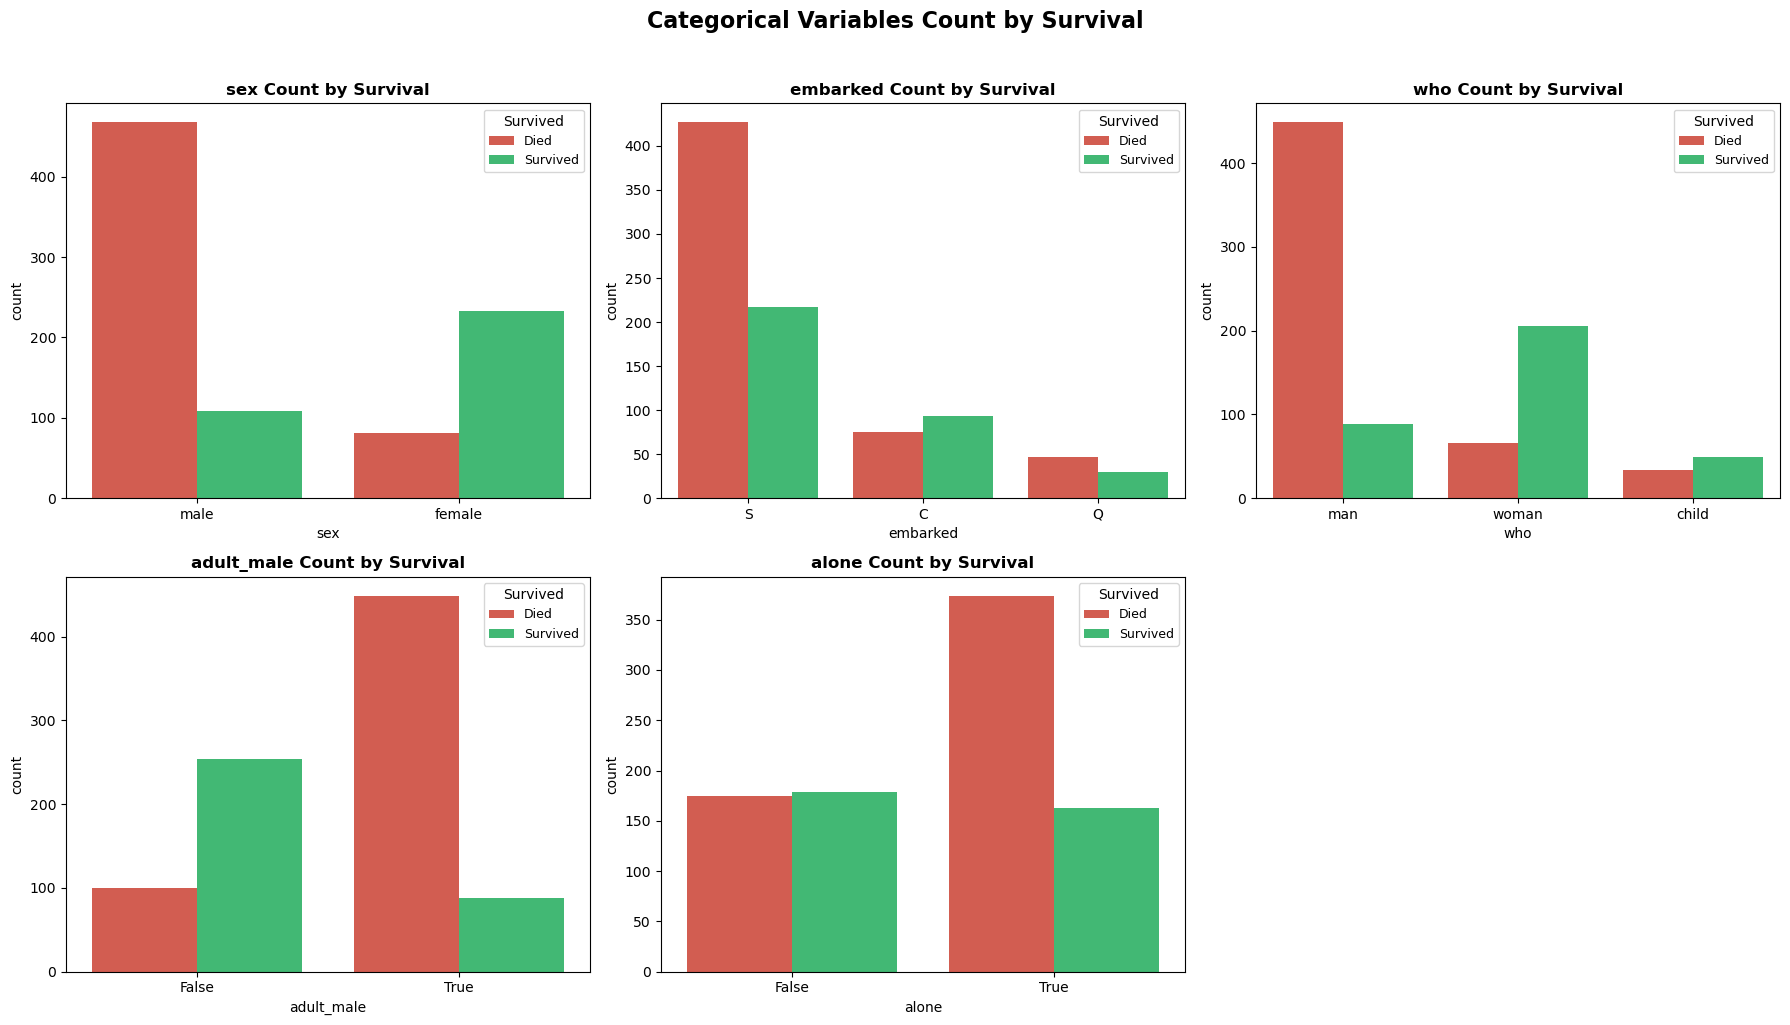

In [5]:
cat_vars = ['sex', 'embarked', 'who', 'adult_male', 'alone']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(cat_vars):
    ax = axes[idx]
    sns.countplot(data=df, x=var, hue='survived', ax=ax, palette={0: '#e74c3c', 1: '#2ecc71'})
    ax.set_title(f'{var} Count by Survival', fontsize=12, fontweight='bold')
    ax.legend(title='Survived', labels=['Died', 'Survived'], fontsize=9)

axes[5].axis('off')

plt.suptitle('Categorical Variables Count by Survival', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_step3_categorical_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 피처-타겟 관계: 생존율 비교

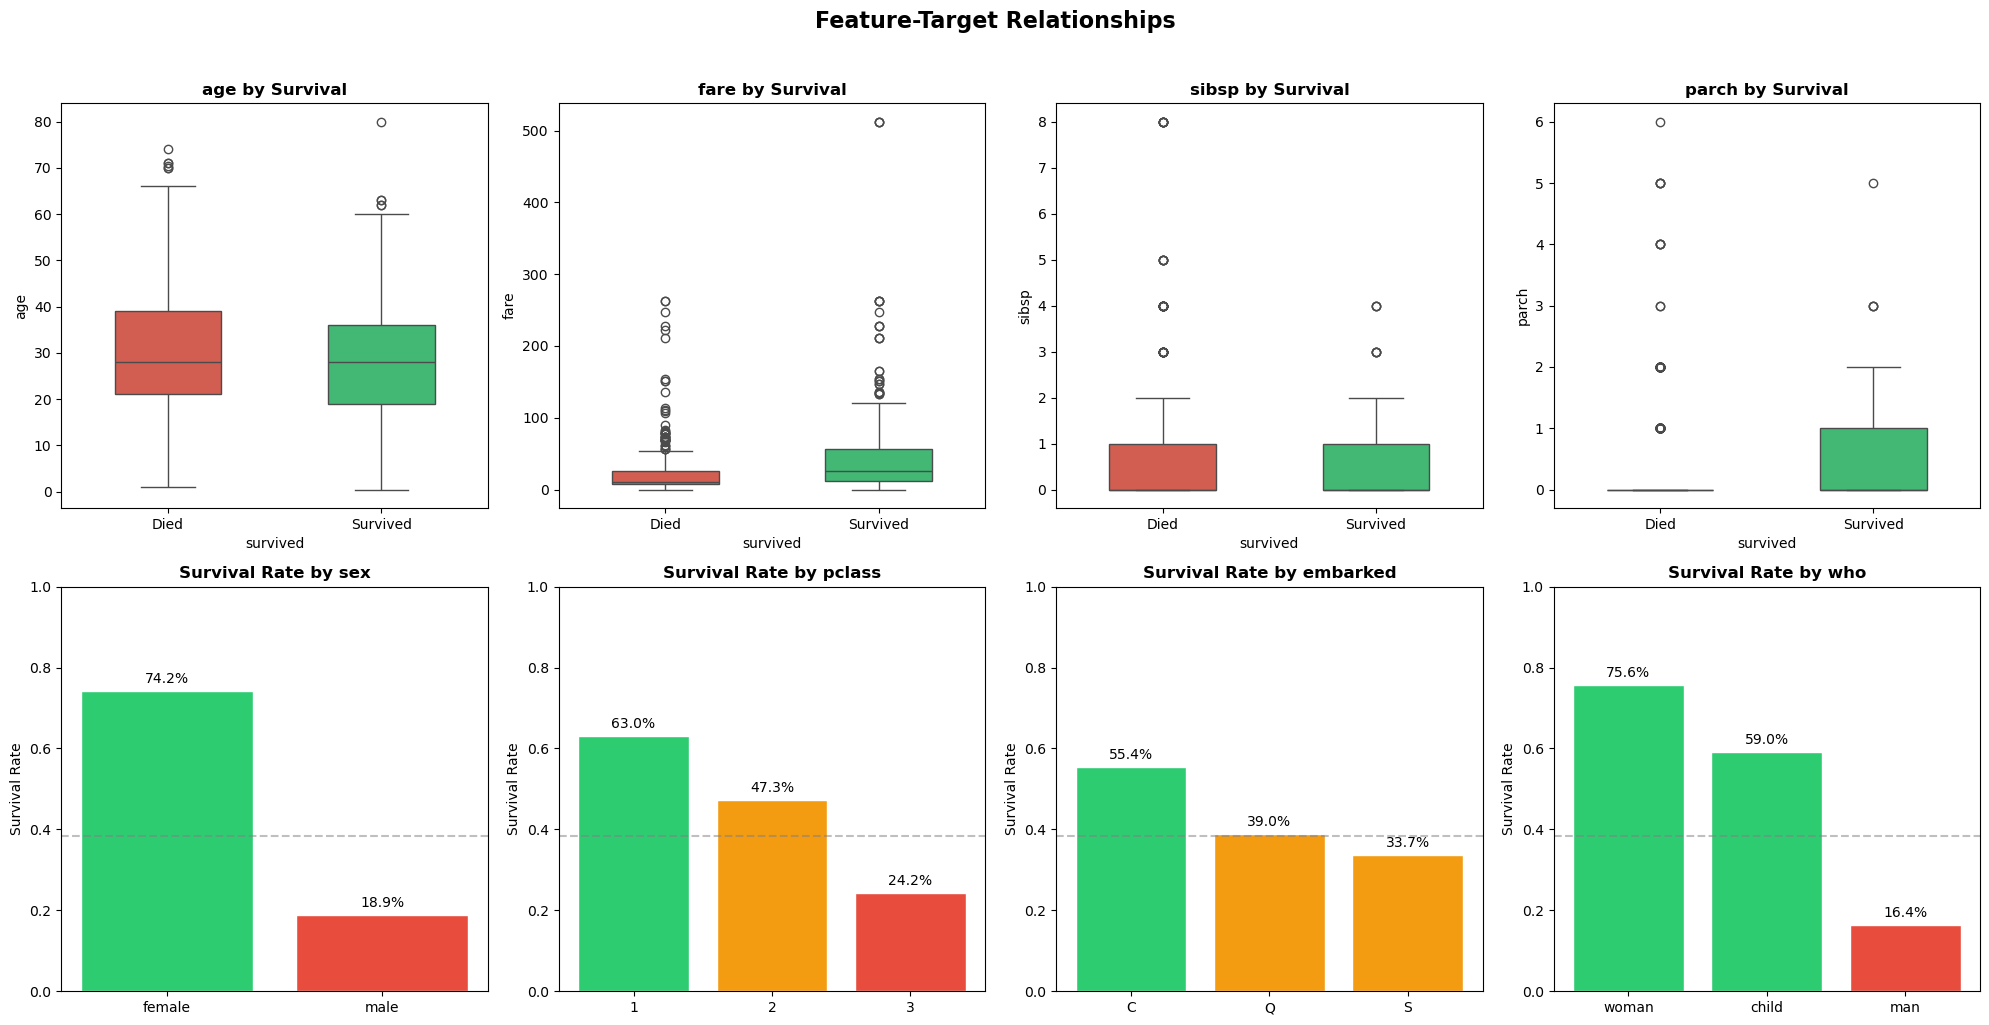

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# 수치형: boxplot by survived
num_vars = ['age', 'fare', 'sibsp', 'parch']
for idx, var in enumerate(num_vars):
    ax = axes[idx]
    sns.boxplot(data=df, x='survived', y=var, ax=ax,
                palette=['#e74c3c', '#2ecc71'], width=0.5)
    ax.set_title(f'{var} by Survival', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Died', 'Survived'])

# 범주형: survival rate bar
cat_surv_vars = ['sex', 'pclass', 'embarked', 'who']
for idx, var in enumerate(cat_surv_vars):
    ax = axes[idx + 4]
    survival_rate = df.groupby(var)['survived'].mean().sort_values(ascending=False)
    colors_sr = ['#2ecc71' if r > 0.5 else '#f39c12' if r > 0.3 else '#e74c3c' for r in survival_rate]
    bars = ax.bar(range(len(survival_rate)), survival_rate.values, color=colors_sr, edgecolor='white')
    ax.set_xticks(range(len(survival_rate)))
    ax.set_xticklabels([str(x) for x in survival_rate.index])
    ax.set_title(f'Survival Rate by {var}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1.0)
    ax.axhline(y=df['survived'].mean(), color='gray', linestyle='--', alpha=0.5)
    for bar, rate in zip(bars, survival_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}', ha='center', fontsize=10)

plt.suptitle('Feature-Target Relationships', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_step3_feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Chi-square 검정 (범주형 변수 독립성)

In [7]:
from scipy.stats import chi2_contingency, mannwhitneyu

print('=' * 60)
print('CHI-SQUARE TEST: Feature vs Survived')
print('=' * 60)

chi_results = []
cat_test_vars = ['sex', 'pclass', 'embarked', 'who', 'adult_male', 'alone']

for var in cat_test_vars:
    ct = pd.crosstab(df[var], df['survived'])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = 'Yes ***' if p < 0.001 else 'Yes **' if p < 0.01 else 'Yes *' if p < 0.05 else 'No'
    chi_results.append({'Variable': var, 'Chi2': chi2, 'p-value': p, 'DoF': dof, 'Significant': sig})

chi_df = pd.DataFrame(chi_results).sort_values('Chi2', ascending=False)
print(chi_df.to_string(index=False, float_format='{:.4f}'.format))

print('\n--- Mann-Whitney U Test (Numeric) ---')
for var in ['age', 'fare', 'sibsp', 'parch']:
    died = df[df['survived'] == 0][var].dropna()
    surv = df[df['survived'] == 1][var].dropna()
    stat, p = mannwhitneyu(died, surv, alternative='two-sided')
    sig = 'Yes ***' if p < 0.001 else 'Yes **' if p < 0.01 else 'Yes *' if p < 0.05 else 'No'
    print(f'  {var:10s}: U={stat:10.1f}, p={p:.6f} -> {sig}')

CHI-SQUARE TEST: Feature vs Survived
  Variable     Chi2  p-value  DoF Significant
       who 283.9231   0.0000    2     Yes ***
adult_male 274.1754   0.0000    1     Yes ***
       sex 260.7170   0.0000    1     Yes ***
    pclass 102.8890   0.0000    2     Yes ***
     alone  36.0005   0.0000    1     Yes ***
  embarked  26.4891   0.0000    2     Yes ***

--- Mann-Whitney U Test (Numeric) ---
  age       : U=   65278.0, p=0.160493 -> No
  fare      : U=   57806.5, p=0.000000 -> Yes ***
  sibsp     : U=   85775.0, p=0.008017 -> Yes **
  parch     : U=   82385.0, p=0.000037 -> Yes ***


## 3.7 deck 특별 분석

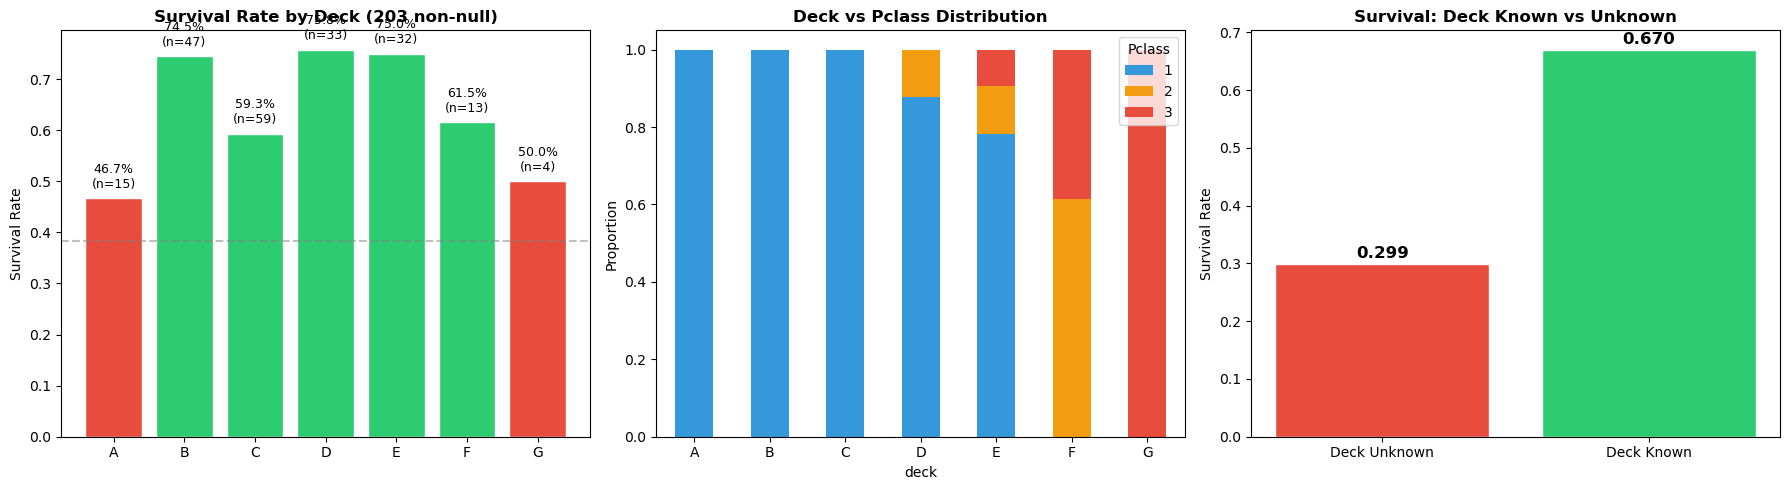


Deck Known: n=203, survival rate=0.670
Deck Unknown: n=688, survival rate=0.299
Chi-square: 89.4346, p-value: 0.000000 -> deck_known is a strong signal!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# deck별 생존율 (비결측만)
ax = axes[0]
deck_data = df[df['deck'].notna()].copy()
deck_survival = deck_data.groupby('deck', observed=True)['survived'].agg(['mean', 'count'])
deck_survival = deck_survival.sort_index()
colors_deck = ['#2ecc71' if r > 0.5 else '#e74c3c' for r in deck_survival['mean']]
bars = ax.bar(range(len(deck_survival)), deck_survival['mean'].values, color=colors_deck, edgecolor='white')
ax.set_xticks(range(len(deck_survival)))
ax.set_xticklabels([str(x) for x in deck_survival.index])
for bar, (rate, count) in zip(bars, deck_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{rate:.1%}\n(n={int(count)})', ha='center', fontsize=9)
ax.set_title('Survival Rate by Deck (203 non-null)', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate')
ax.axhline(y=df['survived'].mean(), color='gray', linestyle='--', alpha=0.5)

# deck vs pclass 분포
ax = axes[1]
deck_pclass = pd.crosstab(deck_data['deck'], deck_data['pclass'], normalize='index')
deck_pclass.plot(kind='bar', stacked=True, ax=ax, color=['#3498db', '#f39c12', '#e74c3c'])
ax.set_title('Deck vs Pclass Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion')
ax.legend(title='Pclass')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# deck 유무에 따른 생존율
ax = axes[2]
df['deck_known'] = df['deck'].notna().astype(int)
dk_survival = df.groupby('deck_known')['survived'].mean()
bars = ax.bar(['Deck Unknown', 'Deck Known'], dk_survival.values,
              color=['#e74c3c', '#2ecc71'], edgecolor='white')
for bar, val in zip(bars, dk_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Survival: Deck Known vs Unknown', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate')

plt.tight_layout()
plt.savefig('../reports/eda_step3_deck_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# deck 통계
print(f'\nDeck Known: n={df["deck_known"].sum()}, survival rate={dk_survival[1]:.3f}')
print(f'Deck Unknown: n={len(df)-df["deck_known"].sum()}, survival rate={dk_survival[0]:.3f}')
ct = pd.crosstab(df['deck_known'], df['survived'])
chi2, p, _, _ = chi2_contingency(ct)
print(f'Chi-square: {chi2:.4f}, p-value: {p:.6f} -> deck_known is a strong signal!')

## 3.8 Safety Check

In [9]:
assert SEED == 42, 'SEED must be 42!'
print('Safety Check Passed!')

Safety Check Passed!


---
## Summary

### 핵심 발견사항

1. **age**: 0-5세 어린이 생존율 가장 높음 (~67%), 결측 여부와 생존율 간 관계 존재
2. **fare**: 극심한 오른쪽 치우침 → log 변환 필수. 0원 티켓 15건 (대부분 3등급 남성, 생존율 매우 낮음)
3. **sex**: Chi-square 가장 높음 - 가장 강력한 예측 변수 확인
4. **pclass**: 등급별 생존율 차이 매우 유의 (1등급 63% vs 3등급 24%)
5. **deck**: 77.2% 결측이지만, deck_known 자체가 강력한 생존 신호 (Chi-square 유의)
6. **who**: child > woman > man 순서 (Chi-square 유의)
7. **모든 주요 변수가 survived와 통계적으로 유의한 관계**

### 피처 활용 가이드
- **필수 피처**: sex, pclass, fare (log 변환), age (대체 후)
- **유용한 피처**: who, adult_male, alone, embarked
- **파생 고려**: deck_known (binary), age_group, log_fare

### 다음 단계
→ **EDA Step 4: 이상치 탐지** 로 진행